# MTH3302 : Méthodes probabilistes et statistiques pour l'I.A.

Jonathan Jalbert<br/>
Professeur titulaire au Département de mathématiques et de génie industriel<br/>
Polytechnique Montréal<br/>


---
# Projet H2024 : Prédiction de la résistance à la compression du béton


Le béton est le matériau le plus important en génie civil. La résistance à la compression du béton est une fonction fortement non linéaire de son âge et de ses constituants. Ces constituants comprennent le ciment, le laitier de haut fourneau, les cendres volantes, l’eau, le superplastifiant, les gros granulats et les granulats fins.

Vous avez accès à une vraie banque de données répertoriant la résistance à la compression du béton en fonction de ses constituants Ces données ont déjà été analysées avec des réseaux de neurones dans plusieurs articles scientifiques, notamment Chen (1998). L'ensemble d'entraînement est constitué de 700 recettes pour lesquelles la résistance est connue. Vous aurez à développer un modèle statisique permettant la prédcition de la résistance des 330 recettes de l'ensemble de test. 

Cheng Yeh, "Modeling of strength of high performance concrete using artificial 
neural networks," Cement and Concrete Research, Vol. 28, No. 12, pp. 1797-1808 (1998)

**But** : Prédire la résistance en compression des recettes de béton de l'ensemble en fonction de leurs caractéristiques.

**Objectifs spécifiques non exhaustifs**
1. Effectuer une analyse exploratoire des données afin d'extraire qualitativement certains les potentiels liens entre les variables.
2. Élaborer plusieurs modèles prédictifs en fonction des caractéristiques fournies.
3. Sélectionner le meilleur modèle prédicitif à l'aide d'un critère choisi.
4. Exploiter le modèle choisi pour effectuer vos prédictions.

Ces étapes peuvent être recommencées autant de fois que nécessaire afin d'obtenir le meilleur modèle prédictif possible.

La description du projet est disponible à l'adresse suivante :
https://www.kaggle.com/t/913327b108f646de84b979c24580541f

Ce calepin Jupyter de base permet de charger les données fournies. La dernière section détaille la génération du fichier des prédictions afin de le soumettre sur Kaggle dans le bon format.

### Données

Dans un premier temps, vous devrez récupérer les données sur Kaggle ou sur le répertoire GitHub du cours. Les fichiers disponibles sont les suivants :
- train.csv
- test.csv

**Déposez ces fichiers dans le répertoire de ce calepin.**

Le fichier *train.csv* contient la résistance en compression du béton en fonction de ses constituants. Voici la description des caractérisiques fournies :

- ID : identifiant de la ligne
- Cement : quantité de ciment en kg par m^3 de béton
- Slag : Laitier de haut fourneau en kg par m^3 de béton
- Ash : Cendres volantes en kg par m^3 de béton
- Water : Eau en kg par m^3 de béton
- Superplasticizer : Superplastifiant en kg par m^3 de béton
- Coarse : Gros granulats en kg par m^3 de béton
- Fine : Fins granulats en kg par m^3 de béton
- Age : Âge en jours
- Strength : Résistance à la compression en MPa

Le fichier *test.csv* contient les 330 recettes de bétons mais pour lesquelles la résistance à la compression sont inconnues. Vous devez prédire la résistance pour chacune de cette recette. Le fichier contient aussi l'identifiant (:ID) pour les prédictions. La qualité de vos prédictions sera ensuite évaluée avec le [*Root Mean Squared Error*](https://en.wikipedia.org/wiki/Root_mean_square_deviation) lorsque vous les téléverserez sur Kaggle. Vos prédictions seront comparées à celles des autres équipes de la classe.


### Consignes

- Vous devez constituer une équipe de 3 à 5 personnes.
- Au moins une solution doit être proposée sur Kaggle.
- Utilisez votre identifiant d'équipe pour téléverser vos prédictions sur Kaggle.
- Un seul calepin *.ipynb* par équipe doit être remis. Ce fichier devra documenter et illustrer la procédure qui vous a permis de produire vos meilleures prédictions. Ce fichier constitue le rapport final du projet.
- Le langage Julia doit être utilisé.
- Votre démarche doit être rigoureusement justifiée (consultez la grille de correction pour vous orienter).

### Quelques conseils

Votre calepin doit **permettre à une personne à l'extérieur de l'équipe de comprendre votre démarche et de reproduire vos résultats**. Par exemple, une bonne façon de faire consiste à expliquer dans une cellule de texte la tâche qui est accomplie dans la cellule de code suivante. 

Je vous encourage fortement à faire une **analyse exploratoire** des données pour développer une meilleure expertise sur le problème. C'est une étape qui est toujours négligée mais qui est essentielle. C'est avec l'analyse exploratoire que vous viendra des idées d'amélioration, comme par exemple créer de nouvelles variables explicatives.

Vous pouvez utiliser directement tout ce qui se trouve dans les notes de cours sans explication et toutes les librairies utilisées dans le cours (incluant mes fonctions).

Ce calepin contient un modèle très simple de prédiction : on n'utilise qu'une seule variable explicative. Ce sera votre travail d'**améliorer ces prédictions** avec la méthode et les variables de votre choix.

S'il y a des **données manquantes**, ce sera à vous de traiter ce problème. Vous devriez développer une méthode d'imputation (de remplacement) des données manquantes.

**Attention aux données aberrantes**. Elles peuvent faire dérailler tous le modèle prédictif si elle ne sont pas prises en compte.

Prenez la peine de **documenter succinctement les essais infructueux**. Ce n'est pas nécessaire de les expliquer en détails, mais c'est important de les mentionner dans la discussion avec une raison possible de leur échec. De cette façon, une personne qui reprendra votre travail dans le futur ne perdra pas de temps à réessayer une méthode infructueuse déjà testée.

Vous pouvez aussi indiquer dans votre rapport les raisons qui vous font croire pourquoi une méthode a moins bien performée de ce qui était attendu. Vous pouvez également mentionner ce que vous auriez pu tenter si vous aviez eu plus de temps ou plus de données. L'idée est de guider l'analyste qui prendrait la relève de votre travail.

Vous êtes **limités à deux soumissions par jour et par équipe sur Kaggle**. Je vous suggère donc de bien tester vos modèles localement et de ne téléverser que vos meilleurs prédictions de la journée.

In [1]:
using CSV, DataFrames, Dates, Gadfly, GLM, Statistics

---
## 1. Chargement de données

In [2]:
train = CSV.read("data/train.csv", DataFrame)
first(train, 5)

Row,ID,Cement,Slag,Ash,Water,Superplasticizer,Coarse,Fine,Age,Strength
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64
1,1,102.0,153.0,0.0,192.0,0.0,887.0,942.0,3,4.57
2,2,153.0,102.0,0.0,192.0,0.0,888.0,943.1,3,4.78
3,3,141.3,212.0,0.0,203.5,0.0,971.8,748.5,3,4.83
4,4,183.9,122.6,0.0,203.5,0.0,959.2,800.0,3,4.9
5,5,385.0,0.0,0.0,186.0,0.0,966.0,763.0,1,6.27


---
## 2. Analyse exploratoire

Cette section consitue une analyse exploratoire superficielle permettant de se familiariser avec les données. C'est une analyse exploratoire sommaire. Je vous encourage fortement à poursuivre cette analyse.

#### 2.1 Résistance en fonction de la quantité de ciment

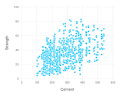

In [3]:
set_default_plot_size(12cm, 10cm)
plot(train, x=:Cement, y=:Strength, Geom.point)

#### 2.2 Résistance en fonction des granulats fins

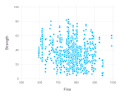

In [4]:
plot(train, x=:Fine, y=:Strength, Geom.point)

---
## 3. Ajustement d'un modèle de régression linéaire

Pour cet exemple simple, on n'utilise que le type d'embarcation pour prédire le prix de vente.

#### 3.1. Ajustement d'un modèle de régression linéaire

Dans ce modèle de base, on utilise la quantité de ciment et de granulats fins pour modéliser la résistance du béton. Notez qu'on considère également l'interaction entre ces deux variables.

L'interaction dans un modèle de régression linéaire se produit lorsque l'effet d'une variable prédictive sur la variable d'intérêt dépend du niveau d'une autre variable. Pour l'inclure, on ajoute un terme produit (la multiplication des deux variables) au modèle, ce qui permet de mesurer comment les variables interagissent entre elles pour influencer le résultat. Cela rend le modèle plus flexible, car il peut estimer des pentes différentes pour différentes combinaisons de variables. 

In [5]:
model = lm(@formula(Strength ~ Cement + Fine + Cement*Fine), train)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

Strength ~ 1 + Cement + Fine + Cement & Fine

Coefficients:
────────────────────────────────────────────────────────────────────────────────────
                      Coef.   Std. Error      t  Pr(>|t|)    Lower 95%     Upper 95%
────────────────────────────────────────────────────────────────────────────────────
(Intercept)    68.2944       15.1375       4.51    <1e-05  38.5738      98.0149
Cement         -0.071173      0.0444282   -1.60    0.1096  -0.158402     0.0160563
Fine           -0.0682006     0.0194494   -3.51    0.0005  -0.106387    -0.0300141
Cement & Fine   0.000188446   5.82256e-5   3.24    0.0013   7.41273e-5   0.000302765
────────────────────────────────────────────────────────────────────────────────────

#### 3.2. Vérification des hypothèses

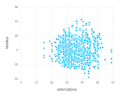

In [6]:
plot(x=predict(model), y=residuals(model), Geom.point,
    Guide.xlabel("estimations"), Guide.ylabel("résidus"))

---
## 4. Estimation de la résistance sur l'ensemble de test

On utilise le modèle simple de la section précédente sur l'ensemble de test.

#### 4.1 Chargement des données de l'ensemble de test

In [7]:
test = CSV.read("data/test.csv", DataFrame)
first(test, 5)

Row,ID,Cement,Slag,Ash,Water,Superplasticizer,Coarse,Fine,Age
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64
1,1,288.0,192.0,0.0,192.0,0.0,932.0,717.8,90
2,2,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
3,3,153.1,145.0,113.0,178.5,8.0,867.2,824.0,28
4,4,332.5,142.5,0.0,228.0,0.0,932.0,594.0,28
5,5,285.0,190.0,0.0,163.0,7.6,1031.0,685.0,28


#### 4.2 Prédictions

In [8]:
predictions = predict(model, test)

330-element Vector{Union{Missing, Float64}}:
 37.79891206162405
 36.24166249840545
 24.973758118640443
 41.337215238612465
 38.08201748561255
 29.585110607327284
 30.957311241860275
 35.00621214943875
 50.3525855881698
 44.05290018001365
  ⋮
 22.00344107540825
 39.26209895614551
 35.4242086014582
 44.212666968791694
 24.95211721562686
 39.02151310002369
 39.1961920362265
 31.410217023931732
 33.07065292580398

#### 4.4 Préparation du fichier des préditions pour téléverser sur Kaggle

Le fichier *benchmark_predictions.csv* généré peut être téléversé sur Kaggle. Il est composé d'une colonne d'identifiants (:ID) et d'une colonne de la prédiction (:Strength).

In [9]:
benchmark_predictions = DataFrame(ID = test.ID, Strength=predictions)
first(benchmark_predictions, 5)

Row,ID,Strength
,Int64,Float64?
1,1,37.7989
2,2,36.2417
3,3,24.9738
4,4,41.3372
5,5,38.082


In [10]:
CSV.write("benchmark_predictions.csv", benchmark_predictions)

"benchmark_predictions.csv"